In [ ]:
# ===============================================
# Code Block 1 — Imports, Paths, Load Events + Scores
# ===============================================

import os
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

IN_DIR  = "../data/processed"
OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

EVENTS_FILE      = os.path.join(IN_DIR, "events_cleaned.csv")
CASE_SCORE_FILE  = os.path.join(IN_DIR, "case_scores.csv")
RES_SCORE_FILE   = os.path.join(IN_DIR, "resource_scores.csv")
OUT_FILE         = os.path.join(OUT_DIR, "event_scores.csv")

events = pd.read_csv(EVENTS_FILE, parse_dates=["timestamp"], low_memory=False)
case_scores = pd.read_csv(CASE_SCORE_FILE)
resource_scores = pd.read_csv(RES_SCORE_FILE)

print("Loaded:")
print(" events:", events.shape)
print(" case_scores:", case_scores.shape)
print(" resource_scores:", resource_scores.shape)


Loaded:
 events: (262628, 14)
 case_scores: (3183, 4)
 resource_scores: (64, 3)


In [20]:
# ===============================================
# Code Block 2 — Ensure required columns & sort
# ===============================================

required = ["case_id", "resource", "timestamp", "activity"]

missing = [c for c in required if c not in events.columns]
if missing:
    raise KeyError(f"Missing required columns for event scoring: {missing}")

# ensure unique event id
if "event_id" not in events.columns:
    events["event_id"] = events.index

# sort for group operations (important)
events = events.sort_values(["case_id", "timestamp"]).reset_index(drop=True)



In [26]:
# ===============================================
# Code Block 3 — Compute gaps, cycle_time, positions,
#                 rework_count_prior, frequencies (SAFE VERSION)
# ===============================================

# --- 1. Compute time gaps for each event ---
events["prev_gap_s"] = (
    events.groupby("case_id")["timestamp"]
    .diff()
    .dt.total_seconds()
)
events["next_gap_s"] = (
    events.groupby("case_id")["timestamp"]
    .shift(-1)
    .sub(events["timestamp"])
    .dt.total_seconds()
)

# Clip negative or bad values
events["prev_gap_s"] = events["prev_gap_s"].clip(lower=0)
events["next_gap_s"] = events["next_gap_s"].clip(lower=0)


# --- 2. Compute case cycle time safely ---
case_bounds = events.groupby("case_id")["timestamp"].agg(
    case_start="min",
    case_end="max"
)
case_bounds["case_cycle_s"] = (
    case_bounds["case_end"] - case_bounds["case_start"]
).dt.total_seconds().replace(0, np.nan)

# If old case_cycle_s exists, remove it (prevents merge collisions)
if "case_cycle_s" in events.columns:
    events = events.drop(columns=["case_cycle_s"])

# Merge cycle time
events = events.merge(
    case_bounds[["case_cycle_s"]].reset_index(),
    on="case_id",
    how="left"
)


# --- 3. Event positions inside each case ---
events["event_index"] = events.groupby("case_id").cumcount()
events["n_events_case"] = events.groupby("case_id")["event_id"].transform("count")
events["event_pos_frac"] = (
    events["event_index"] / (events["n_events_case"] - 1 + 1e-12)
)

events["is_first_event"] = (events["event_index"] == 0).astype(int)
events["is_last_event"]  = (events["event_index"] == events["n_events_case"] - 1).astype(int)


# --- 4. Rework as count of prior occurrences ---
events["rework_count_prior"] = (
    events.groupby(["case_id", "activity"]).cumcount()
)


# --- 5. Gap ratio relative to case cycle ---
events["gap_ratio_prev"] = (
    events["prev_gap_s"] / (events["case_cycle_s"] + 1e-12)
)


# --- 6. Activity frequency (global) ---
if "activity" in events.columns:
    activity_freq = (
        events["activity"]
        .value_counts(normalize=True)
        .rename("activity_freq")
        .reset_index()
        .rename(columns={"index": "activity"})
    )

    events = events.merge(
        activity_freq,
        on="activity",
        how="left"
    )
else:
    events["activity_freq"] = np.nan


# --- 7. Resource frequency (global) ---
if "resource" in events.columns:
    resource_freq = (
        events["resource"]
        .value_counts(normalize=True)
        .rename("resource_freq")
        .reset_index()
        .rename(columns={"index": "resource"})
    )

    events = events.merge(
        resource_freq,
        on="resource",
        how="left"
    )
else:
    events["resource_freq"] = np.nan


# --- 8. Attach case_score & resource_score ---
events = events.merge(
    case_scores[["case_id", "case_score"]],
    on="case_id",
    how="left"
)
events = events.merge(
    resource_scores[["resource", "resource_score"]],
    on="resource",
    how="left"
)

events["case_score"] = events["case_score"].fillna(events["case_score"].median())
events["resource_score"] = events["resource_score"].fillna(events["resource_score"].median())


# --- Sanity check display ---
print("Sample event features after Block 3:")
display(events.head(12))
print("Columns now present:")
display(events.columns.tolist())


Sample event features after Block 3:


,case_id,timestamp,activity,resource,cost,municipality,case_status,case_procedure,event_id,all_properties,...,is_first_event,is_last_event,rework_count_prior,gap_ratio_prev,case_cycle_s_y,case_cycle_s,activity_freq,resource_freq,case_score,resource_score
0,10002463,2014-08-05 00:00:00+00:00,register submission date request,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":136730,""labels"":[""Event""],""properties"":{...",...,1,0,0,NaN,5486152.0,5486152.0,0.021490,0.049024,0.686,0.166
1,10002463,2014-08-06 00:00:00+00:00,regular procedure without MER,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137411,""labels"":[""Event""],""properties"":{...",...,0,0,0,0.015749,5486152.0,5486152.0,0.020775,0.049024,0.686,0.166
2,10002463,2014-08-06 00:00:00+00:00,create procedure confirmation,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137412,""labels"":[""Event""],""properties"":{...",...,0,0,0,0.000000,5486152.0,5486152.0,0.009938,0.049024,0.686,0.166
3,10002463,2014-08-06 00:00:00+00:00,publish,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137413,""labels"":[""Event""],""properties"":{...",...,0,0,0,0.000000,5486152.0,5486152.0,0.005156,0.049024,0.686,0.166
4,10002463,2014-08-06 00:00:00+00:00,create subcases completeness,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137414,""labels"":[""Event""],""properties"":{...",...,0,0,0,0.000000,5486152.0,5486152.0,0.009314,0.049024,0.686,0.166
5,10002463,2014-08-06 00:00:00+00:00,procedure change,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137415,""labels"":[""Event""],""properties"":{...",...,0,0,0,0.000000,5486152.0,5486152.0,0.032933,0.049024,0.686,0.166
6,10002463,2014-08-06 00:00:00+00:00,OLO messaging active,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137416,""labels"":[""Event""],""properties"":{...",...,0,0,0,0.000000,5486152.0,5486152.0,0.014557,0.049024,0.686,0.166
7,10002463,2014-08-06 00:00:00+00:00,send confirmation receipt,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137417,""labels"":[""Event""],""properties"":{...",...,0,0,0,0.000000,5486152.0,5486152.0,0.034612,0.049024,0.686,0.166
8,10002463,2014-08-06 00:00:00+00:00,forward to the competent authority,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137418,""labels"":[""Event""],""properties"":{...",...,0,0,0,0.000000,5486152.0,5486152.0,0.020946,0.049024,0.686,0.166
9,10002463,2014-08-06 00:00:00+00:00,send procedure confirmation,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137419,""labels"":[""Event""],""properties"":{...",...,0,0,0,0.000000,5486152.0,5486152.0,0.013601,0.049024,0.686,0.166


Columns now present:


['case_id',
 'timestamp',
 'activity',
 'resource',
 'cost',
 'municipality',
 'case_status',
 'case_procedure',
 'event_id',
 'all_properties',
 'year',
 'month',
 'weekday',
 'hour',
 'prev_gap_s',
 'next_gap_s',
 'case_cycle_s_x',
 'event_index',
 'n_events_case',
 'event_pos_frac',
 'is_first_event',
 'is_last_event',
 'rework_count_prior',
 'gap_ratio_prev',
 'case_cycle_s_y',
 'case_cycle_s',
 'activity_freq',
 'resource_freq',
 'case_score',
 'resource_score']

In [27]:
# ===============================================
# Code Block 4 — Build event metric matrix and transforms
# ===============================================

# build event metrics DataFrame
event_metrics = pd.DataFrame(index=events.index)

# compress gaps with log1p to reduce extreme influence
event_metrics["prev_gap_log"] = np.log1p(events["prev_gap_s"].fillna(0.0))
event_metrics["next_gap_log"] = np.log1p(events["next_gap_s"].fillna(0.0))

# gap ratio log
event_metrics["gap_ratio_prev_log"] = np.log1p(events["gap_ratio_prev"].fillna(0.0))

# graded rework (higher = worse) - we will invert later
event_metrics["rework_prior"] = events["rework_count_prior"].astype(float)

# position metric: events in middle considered maybe better; we include fraction as is
event_metrics["event_pos_frac"] = events["event_pos_frac"].astype(float)

# activity/resource frequency (higher freq might be better: more routine)
event_metrics["activity_freq"] = events["activity_freq"].astype(float)
event_metrics["resource_freq"] = events["resource_freq"].astype(float)

# include case & resource aggregated scores (already 0-1 but ensure numeric)
event_metrics["case_score"]     = events["case_score"].astype(float)
event_metrics["resource_score"] = events["resource_score"].astype(float)

# preview
print("Raw event_metrics preview:")
display(event_metrics.head())



Raw event_metrics preview:


,prev_gap_log,next_gap_log,gap_ratio_prev_log,rework_prior,event_pos_frac,activity_freq,resource_freq,case_score,resource_score
0,0.000000,11.366755,0.000000,0.0,-0.0,0.021490,0.049024,0.686,0.166
1,11.366755,0.000000,0.015626,0.0,-1.0,0.020775,0.049024,0.686,0.166
2,0.000000,0.000000,0.000000,0.0,-2.0,0.009938,0.049024,0.686,0.166
3,0.000000,0.000000,0.000000,0.0,-3.0,0.005156,0.049024,0.686,0.166
4,0.000000,0.000000,0.000000,0.0,-4.0,0.009314,0.049024,0.686,0.166


In [28]:
# ===============================================
# Code Block 5 — Normalization: use percentile rank (0-1) and consistent direction
# ===============================================

# Percentile rank function (0..1)
def pct_rank_series(s):
    # use rank method 'average' then scale to [0,1]
    return s.rank(method="average", pct=True)

# We want higher=better for all metrics.
# For metrics where lower is better (gaps, rework_prior, gap_ratio), invert after ranking.

norm = pd.DataFrame(index=event_metrics.index)

# prev/next gap: lower gap = better -> rank then invert
norm["prev_gap"] = 1.0 - pct_rank_series(event_metrics["prev_gap_log"].fillna(0.0))
norm["next_gap"] = 1.0 - pct_rank_series(event_metrics["next_gap_log"].fillna(0.0))

# gap_ratio: lower = better
norm["gap_ratio_prev"] = 1.0 - pct_rank_series(event_metrics["gap_ratio_prev_log"].fillna(0.0))

# rework_prior: lower = better
norm["rework_prior"] = 1.0 - pct_rank_series(event_metrics["rework_prior"].fillna(0.0))

# event position: choose interpretation — earlier events may be more critical.
# We'll treat middle events slightly better: we build pos_score = 1 - abs(0.5 - frac)*2  -> 1 at center, 0 at ends
pos_raw = 1.0 - (np.abs(0.5 - event_metrics["event_pos_frac"]) * 2.0)
norm["event_pos"] = pct_rank_series(pos_raw.fillna(pos_raw.median()))

# activity/resource freq: higher freq = more routine = better
norm["activity_freq"] = pct_rank_series(event_metrics["activity_freq"].fillna(0.0))
norm["resource_freq"] = pct_rank_series(event_metrics["resource_freq"].fillna(0.0))

# case & resource scores: already 0..1 from earlier but ensure rank scaling to align distributions
norm["case_score"] = pct_rank_series(event_metrics["case_score"].fillna(event_metrics["case_score"].median()))
norm["resource_score"] = pct_rank_series(event_metrics["resource_score"].fillna(event_metrics["resource_score"].median()))

print("Normalized (rank-based) event metrics preview:")
display(norm.head())


Normalized (rank-based) event metrics preview:


,prev_gap,next_gap,gap_ratio_prev,rework_prior,event_pos,activity_freq,resource_freq,case_score,resource_score
0,0.722033,0.056715,0.722033,0.738015,0.993942,0.861258,0.369477,0.723095,0.468979
1,0.056715,0.722033,0.054488,0.738015,0.981828,0.808434,0.369477,0.723095,0.468979
2,0.722033,0.722033,0.722033,0.738015,0.969725,0.383613,0.369477,0.723095,0.468979
3,0.722033,0.722033,0.722033,0.738015,0.957642,0.168541,0.369477,0.723095,0.468979
4,0.722033,0.722033,0.722033,0.738015,0.945583,0.354846,0.369477,0.723095,0.468979


In [29]:
# ===============================================
# Code Block 6 — Clean NaNs, drop constants, prepare for PCA
# ===============================================

# clean
norm = norm.replace([np.inf, -np.inf], np.nan)
norm = norm.fillna(norm.median())

# drop constant columns (no variance)
constant_cols = [c for c in norm.columns if norm[c].std() == 0]
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    norm = norm.drop(columns=constant_cols)

# final check
if norm.isna().sum().sum() > 0:
    norm = norm.fillna(0)

print("event_norm ready for PCA. shape:", norm.shape)
display(norm.describe().T)


event_norm ready for PCA. shape: (262628, 9)


,count,mean,std,min,25%,50%,75%,max
prev_gap,262628.0,0.499998,0.262640,0.000000,0.254624,0.722033,0.722033,0.722033
next_gap,262628.0,0.499998,0.262640,0.000000,0.254624,0.722033,0.722033,0.722033
gap_ratio_prev,262628.0,0.499998,0.262698,0.000059,0.250004,0.722033,0.722033,0.722033
rework_prior,262628.0,0.499998,0.267095,0.000000,0.250025,0.738015,0.738015,0.738015
event_pos,262628.0,0.500002,0.288668,0.000004,0.250003,0.501763,0.751462,0.993942
activity_freq,262628.0,0.500002,0.288624,0.000061,0.246716,0.506187,0.752898,0.982696
resource_freq,262628.0,0.500002,0.288162,0.000015,0.245286,0.520596,0.780288,0.954881
case_score,262628.0,0.500002,0.276642,0.216900,0.216900,0.501207,0.750360,0.999996
resource_score,262628.0,0.500002,0.288162,0.044508,0.215055,0.505196,0.756654,0.999989


In [30]:
# ===============================================
# Code Block 7 — PCA + Entropy weighting
# ===============================================

# PCA weights
scaler = StandardScaler()
X = scaler.fit_transform(norm)

pca = PCA(n_components=1, random_state=42)
pca.fit(X)
loadings = np.abs(pca.components_[0])
w_pca = loadings / loadings.sum()

# Entropy weights (on minmax-scaled data)
mm = MinMaxScaler()
vals = mm.fit_transform(norm)
P = vals / (vals.sum(axis=0) + 1e-12)
E = np.array([entropy(P[:,i]) for i in range(P.shape[1])])
d = 1 - E / np.log(len(P))
w_entropy = d / d.sum()

# Combine, but cap the influence of any single metric to avoid domination (optional safeguard)
w_comb = (w_pca + w_entropy) / 2.0
# cap maximum weight to 0.45 (prevents single metric overwhelming the score)
cap = 0.45
w_comb = np.minimum(w_comb, cap)
w_comb = w_comb / w_comb.sum()

event_weights = dict(zip(norm.columns, w_comb))

print("Event weights (final, columns -> weight):")
for k,v in event_weights.items():
    print(f"{k}: {v:.3f}")


Event weights (final, columns -> weight):
prev_gap: 0.088
next_gap: 0.073
gap_ratio_prev: 0.097
rework_prior: 0.151
event_pos: 0.156
activity_freq: 0.055
resource_freq: 0.062
case_score: 0.250
resource_score: 0.067


In [31]:
# ===============================================
# Code Block 8 — Compute event score, round, save
# ===============================================

# compute raw score
event_raw = np.zeros(len(norm))
for col in norm.columns:
    event_raw += norm[col].values * event_weights[col]

# normalize to 0..1
event_score = (event_raw - event_raw.min()) / (event_raw.max() - event_raw.min() + 1e-12)
events["event_score"] = np.round(event_score, 3)

# attach normalized submetrics (3 decimals) for inspection
for col in norm.columns:
    events[f"ev_{col}"] = np.round(norm[col].values, 3)

# save
out_cols = ["event_id", "case_id", "resource", "event_score"] + [f"ev_{c}" for c in norm.columns]
out_df = events[out_cols].copy()
out_df.to_csv(OUT_FILE, index=False)

print("Saved event_scores.csv:", OUT_FILE)
print("event_scores shape:", out_df.shape)
display(out_df.head(10))


Saved event_scores.csv: ../data/processed\event_scores.csv
event_scores shape: (262628, 13)


,event_id,case_id,resource,event_score,ev_prev_gap,ev_next_gap,ev_gap_ratio_prev,ev_rework_prior,ev_event_pos,ev_activity_freq,ev_resource_freq,ev_case_score,ev_resource_score
0,NaN,10002463,1550894,0.792,0.722,0.057,0.722,0.738,0.994,0.861,0.369,0.723,0.469
1,NaN,10002463,1550894,0.672,0.057,0.722,0.054,0.738,0.982,0.808,0.369,0.723,0.469
2,NaN,10002463,1550894,0.819,0.722,0.722,0.722,0.738,0.970,0.384,0.369,0.723,0.469
3,NaN,10002463,1550894,0.798,0.722,0.722,0.722,0.738,0.958,0.169,0.369,0.723,0.469
4,NaN,10002463,1550894,0.811,0.722,0.722,0.722,0.738,0.946,0.355,0.369,0.723,0.469
5,NaN,10002463,1550894,0.857,0.722,0.722,0.722,0.738,0.934,0.949,0.369,0.723,0.469
6,NaN,10002463,1550894,0.817,0.722,0.722,0.722,0.738,0.922,0.492,0.369,0.723,0.469
7,NaN,10002463,1550894,0.854,0.722,0.722,0.722,0.738,0.910,0.983,0.369,0.723,0.469
8,NaN,10002463,1550894,0.839,0.722,0.722,0.722,0.738,0.898,0.829,0.369,0.723,0.469
9,NaN,10002463,1550894,0.805,0.722,0.722,0.722,0.738,0.886,0.450,0.369,0.723,0.469


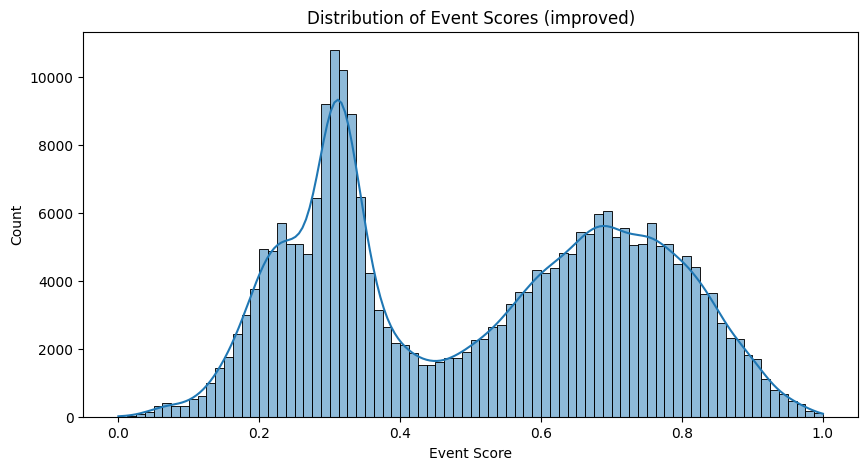

Event score summary:


count    262628.000
mean          0.513
std           0.229
min           0.000
25%           0.305
50%           0.535
75%           0.715
max           1.000
Name: event_score, dtype: float64

Top 10 events by score:


,event_id,case_id,resource,event_score
142864,NaN,9368907,4901428,1.000
12618,NaN,11776310,560464,1.000
137559,NaN,8907898,4901428,0.999
13891,NaN,12096555,4901428,0.999
126518,NaN,7954530,4901428,0.999
14378,NaN,12189231,4901428,0.999
111843,NaN,7049922,560696,0.998
133995,NaN,8480760,560696,0.998
133809,NaN,8463513,560696,0.997
133734,NaN,8452404,560696,0.997


Bottom 10 events by score:


,event_id,case_id,resource,event_score
259461,NaN,Unknown,560458,0.000
242392,NaN,Unknown,560812,0.013
259576,NaN,Unknown,560458,0.015
260372,NaN,Unknown,1550894,0.015
261298,NaN,Unknown,560458,0.015
241434,NaN,Unknown,560812,0.015
261161,NaN,Unknown,1550894,0.016
258987,NaN,Unknown,560852,0.018
258040,NaN,Unknown,560852,0.018
242705,NaN,Unknown,560812,0.019


In [32]:
# ===============================================
# Code Block 9 — Diagnostics plots
# ===============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(events["event_score"], kde=True, bins=80)
plt.title("Distribution of Event Scores (improved)")
plt.xlabel("Event Score")
plt.show()

# show summary
print("Event score summary:")
display(events["event_score"].describe().round(3))

print("Top 10 events by score:")
display(events.sort_values("event_score", ascending=False).head(10)[["event_id","case_id","resource","event_score"]])

print("Bottom 10 events by score:")
display(events.sort_values("event_score", ascending=True).head(10)[["event_id","case_id","resource","event_score"]])

